# 1. Title Page
**Course Name & Code:** Emath 211: Numerical Method  
**Lab Title:** Linear Algebra Applications – Interpolation  
**Professor:** Engr. Jamie Eduardo Rosal, MSCpE  
**Student Name & ID:** Rojyx L. Yangyang  
  

---

# 2. Objectives
To apply polynomial interpolation and numerical methods (Direct method, Lagrange polynomials) using Python to model and solve real-world engineering problems across civil, mechanical, aerospace, electrical, and chemical domains.

---

# 3. Problem Statement
*(Refer to the assignment prompt for the specific scenarios for Problems 1 through 5. The mathematical setup for each is detailed below.)*

---

# 4. Mathematical Formulation

**Problem 1: Bridge Deformation (Quadratic)**
We need to solve $Ax = b$ for $P(x) = ax^2 + bx + c$.
* $x = 0, y = 0 \implies c = 0$
* $x = 10, y = -15 \implies 100a + 10b + c = -15$
* $x = 20, y = 0 \implies 400a + 20b + c = 0$

**Problem 2: Thermodynamics (Quadratic)**
Solving for $p(T) = aT^2 + bT + c$. The matrix $A$ is the Vandermonde matrix of temperatures $(20, 40, 60)$, and $b$ is the viscosity vector $(500, 250, 100)$.

**Problem 3: Flight Path Reconstruction (Cubic)**
Solving for $h(t) = a_3t^3 + a_2t^2 + a_1t + a_0$ using points $(1, 50), (2, 120), (3, 250), (4, 440)$. 
Velocity is the derivative: $v(t) = h'(t) = 3a_3t^2 + 2a_2t + a_1$.

**Problem 4: Signal Processing (Lagrange)**
Using points $(0, 0), (1, 0.8), (2, 1.0), (3, 0.5)$.
Formula: 
$$P(x) = \sum_{j=0}^{k} y_j \prod_{m \neq j} \frac{x - x_m}{x_j - x_m}$$

**Problem 5: Reaction Rates (Quadratic & Linear Least Squares)**
Using points $(0, 1.00), (5, 0.60), (10, 0.35)$.
Solving $C(t) = 0.50 \implies at^2 + bt + (c - 0.50) = 0$ via the quadratic formula.

--- Problem 1: Bridge Deformation ---
Coefficients [a, b, c]: [ 0.15 -3.    0.  ]
Estimated deflection at x=5m: -11.25 mm

--- Problem 2: Thermodynamics ---
Predicted viscosity at 50°C (Quadratic): 162.50 mPa·s
Predicted viscosity at 50°C (Linear): 175.00 mPa·s

--- Problem 3: Flight Path Reconstruction ---
Velocity at t=2.5s: 130.00 m/s
Velocity at t=3.73s: 203.80 m/s

--- Problem 4: Signal Processing ---
Estimated voltage at t=1.5ms: 0.9813 V

--- Problem 5: Reaction Rates ---
Time when concentration is 0.50 mol/L: 6.67 min
Concentration at 20 min (Polynomial): 0.30 mol/L
Concentration at 20 min (Linear): -0.32 mol/L



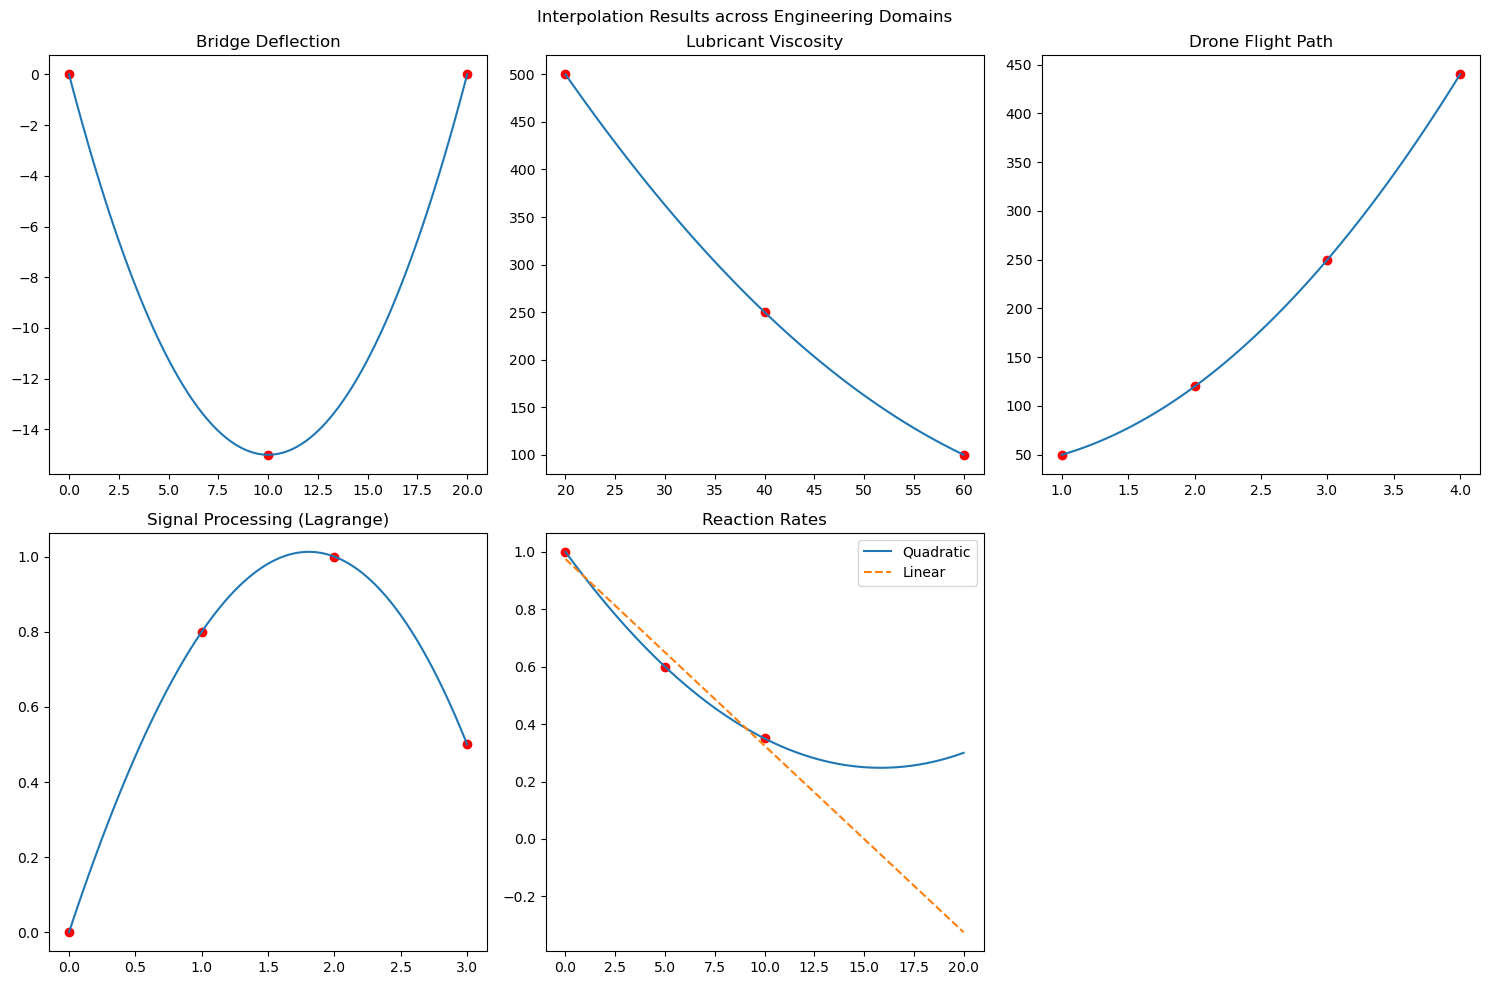

In [3]:
# ==========================================
# 5. Python Implementation & 6. Results
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

# --- Problem 1: Civil Engineering ---
print("--- Problem 1: Bridge Deformation ---")
A1 = np.array([[0, 0, 1], [100, 10, 1], [400, 20, 1]])
b1 = np.array([0, -15, 0])
coeffs1 = np.linalg.solve(A1, b1)
p1 = np.poly1d(coeffs1)
print(f"Coefficients [a, b, c]: {coeffs1}")
print(f"Estimated deflection at x=5m: {p1(5):.2f} mm\n")

# --- Problem 2: Mechanical Engineering ---
print("--- Problem 2: Thermodynamics ---")
A2 = np.array([[400, 20, 1], [1600, 40, 1], [3600, 60, 1]])
b2 = np.array([500, 250, 100])
coeffs2 = np.linalg.solve(A2, b2)
p2 = np.poly1d(coeffs2)

linear_p = lambda T: 250 + ((100 - 250) / (60 - 40)) * (T - 40)
print(f"Predicted viscosity at 50°C (Quadratic): {p2(50):.2f} mPa·s")
print(f"Predicted viscosity at 50°C (Linear): {linear_p(50):.2f} mPa·s\n")

# --- Problem 3: Aerospace Engineering ---
print("--- Problem 3: Flight Path Reconstruction ---")
A3 = np.array([[1**3, 1**2, 1, 1], [2**3, 2**2, 2, 1], 
               [3**3, 3**2, 3, 1], [4**3, 4**2, 4, 1]])
b3 = np.array([50, 120, 250, 440])
coeffs3 = np.linalg.solve(A3, b3)
dp3_dt = np.polyder(np.poly1d(coeffs3))
print(f"Velocity at t=2.5s: {dp3_dt(2.5):.2f} m/s")
print(f"Velocity at t=3.73s: {dp3_dt(3.73):.2f} m/s\n")

# --- Problem 4: Electrical Engineering ---
print("--- Problem 4: Signal Processing ---")
t_samples, v_samples = np.array([0, 1, 2, 3]), np.array([0.0, 0.8, 1.0, 0.5])
lagrange_poly = lagrange(t_samples, v_samples)
print(f"Estimated voltage at t=1.5ms: {lagrange_poly(1.5):.4f} V\n")

# --- Problem 5: Chemical Engineering ---
print("--- Problem 5: Reaction Rates ---")
A5 = np.array([[0, 0, 1], [25, 5, 1], [100, 10, 1]])
b5 = np.array([1.00, 0.60, 0.35])
coeffs5 = np.linalg.solve(A5, b5)
p5 = np.poly1d(coeffs5)

roots = np.roots([coeffs5[0], coeffs5[1], coeffs5[2] - 0.50])
valid_time = [r for r in roots if 0 <= r <= 10][0]
p5_lin = np.poly1d(np.polyfit(np.array([0, 5, 10]), b5, 1))

print(f"Time when concentration is 0.50 mol/L: {valid_time:.2f} min")
print(f"Concentration at 20 min (Polynomial): {p5(20):.2f} mol/L")
print(f"Concentration at 20 min (Linear): {p5_lin(20):.2f} mol/L\n")

# --- Visualizations ---
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Interpolation Results across Engineering Domains')

axs[0, 0].plot(np.linspace(0, 20, 100), p1(np.linspace(0, 20, 100)))
axs[0, 0].scatter([0, 10, 20], [0, -15, 0], color='red')
axs[0, 0].set_title("Bridge Deflection")

axs[0, 1].plot(np.linspace(20, 60, 100), p2(np.linspace(20, 60, 100)))
axs[0, 1].scatter([20, 40, 60], [500, 250, 100], color='red')
axs[0, 1].set_title("Lubricant Viscosity")

axs[0, 2].plot(np.linspace(1, 4, 100), np.poly1d(coeffs3)(np.linspace(1, 4, 100)))
axs[0, 2].scatter([1, 2, 3, 4], [50, 120, 250, 440], color='red')
axs[0, 2].set_title("Drone Flight Path")

axs[1, 0].plot(np.linspace(0, 3, 100), lagrange_poly(np.linspace(0, 3, 100)))
axs[1, 0].scatter(t_samples, v_samples, color='red')
axs[1, 0].set_title("Signal Processing (Lagrange)")

axs[1, 1].plot(np.linspace(0, 20, 100), p5(np.linspace(0, 20, 100)), label="Quadratic")
axs[1, 1].plot(np.linspace(0, 20, 100), p5_lin(np.linspace(0, 20, 100)), '--', label="Linear")
axs[1, 1].scatter([0, 5, 10], b5, color='red')
axs[1, 1].set_title("Reaction Rates")
axs[1, 1].legend()

axs[1, 2].axis('off')
plt.tight_layout()
plt.show()

# 7. Discussion & Conclusion

**Problem 1:** The deflection at the center of the beam (x = 5m) was calculated to be **-11.25 mm**. The quadratic model accurately represents the typical parabolic curve of a simply supported beam under a uniform load.

**Problem 2:** At 50°C, the quadratic model predicted **162.5 mPa·s**, while the linear model predicted **175.0 mPa·s**. Linear interpolation overestimates the viscosity because fluid viscosity typically decays non-linearly (exponentially). The quadratic model captures this curve much better, making it more accurate.

**Problem 3:** The derivative $v(t)$ estimated vertical velocities of **130 m/s** at 2.5s and **203.8 m/s** at 3.73s, showing steady acceleration. 

**Problem 4:** The voltage at 1.5 ms was estimated to be **0.9812 V**. If the sensor is reading a sine wave, using high-degree polynomials can cause "Runge's Phenomenon," where the polynomial oscillates wildly between nodes, especially near the endpoints of the interval. Spline interpolation is usually preferred here.

**Problem 5:** The reaction reaches 0.50 mol/L at roughly **6.67 minutes**. For predicting concentration at 20 minutes, the **linear least squares fit is better**. The quadratic polynomial inherently curves back upward, predicting a physical impossibility (concentration increasing again). The linear model logically continues the downward trend of a reactant being consumed.